{'topic': '猫咪', 'poem': '好的，这里有一首关于猫咪的诗：\n\n**猫**\n\n一身绒毛软又轻，\n姿态优雅步无声。\n琥珀眼眸藏灵动，\n静卧窗台享暖风。\n\n蜷成一团睡意浓，\n喉间轻转咕噜声。\n忽而跃起追蝶影，\n爪尖轻舞捕风中。\n\n独立高傲不羁身，\n却也柔情伴主人。\n轻蹭腿边撒娇态，\n一声喵呜暖人心。\n\n它是家中一道景，\n神秘优雅又温馨。\n无言陪伴度光阴，\n愿它安好享太平。', 'content_type': '诗'}
{'topic': '猫咪', 'joke': '好的，来一个关于猫咪的笑话：\n\n主人：“小猫，你每天在家除了吃就是睡，到底有什么‘工作’啊？”\n\n猫咪（打了个哈欠，伸了个懒腰）：“当然有啊！我的工作可多了！”\n\n主人：“比如呢？”\n\n猫咪：“首先，我得负责检查家里的沙发和床够不够软，适不适合我睡觉。”\n“其次，我得监督你有没有按时给我喂饭，确保食物的质量和数量。”\n“最重要的是，我还要时不时地在你脚边蹭一蹭，提醒你——**这个家，究竟是谁说了算！**”', 'content_type': '笑话'}


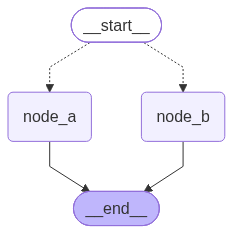

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	node_a(node_a)
	node_b(node_b)
	__end__([<p>__end__</p>]):::last
	__start__ -.-> node_a;
	__start__ -.-> node_b;
	node_a --> __end__;
	node_b --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [ ]:
from typing import TypedDict,Literal
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from rich import print as rprint
from dotenv import load_dotenv
import os

load_dotenv(override=True)

GEMINI_API_KEY=os.getenv("GEMINI_API_KEY")
GEMINI_BASE_URL=os.getenv("GEMINI_BASE_URL")

model = init_chat_model(
  model="gemini-2.5-flash",
  model_provider="google_genai",
  api_key=GEMINI_API_KEY,
  transport="rest"  # 强制使用 REST 协议
)

#1. 定义状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    content_type: str

#2. 定义节点
def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke([f"写一首关于{state['topic']}主题的诗"]).content
    return {
        "poem": poem
    }

def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke([f"写一个关于{state['topic']}主题的笑话"]).content
    return {
        "joke": joke
    }

def my_route(state: OverAllState) -> Literal["node_a","node_b"]:
    if "诗" in state["content_type"]:
        return "node_a"
    else:
        return "node_b"


#3. 构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node(node_a)
builder.add_node(node_b)
builder.add_conditional_edges(START,my_route)
builder.add_edge("node_b",END)
builder.add_edge("node_a",END)

graph = builder.compile()
poem_res = graph.invoke({"topic": "猫咪","content_type":"诗"})
print(poem_res)

joke_res = graph.invoke({"topic": "猫咪","content_type":"笑话"})
print(joke_res)

from IPython.display import display
display(graph)

raw_mermaid = graph.get_graph().draw_mermaid()
print(raw_mermaid)
